---
title: "Deep Learning for Krusell-Smith"
subtitle: "Sequel to *Deep Learning Methods for Solving Dynamic Economic Models*"
author:
  - name: "Lecturer: Bo Li"
    affiliation: "School of Economics, Peking University"
    email: "libo.econ@pku.edu.cn"
  - name: "TA: Chen Gao"
    affiliation: "National School of Development, Peking University"
    email: "chengao0716@gmail.com"
date: today
format:
  revealjs:
    embed-resources: true
    smaller: true
    echo: true
    urlcolor: orange
    toc: true
    toc-depth: 1
    transition: fade
    code-block-height: 400px
    slide-number: c/t
    show-slide-number: all

  pdf:
    toc: true
    toc-depth: 1
    monofont: "Fira Code"
    mainfont: "Libertinus Serif"
    mathfont: "Libertinus Math"
    sansfont: "Fira Sans"
    urlcolor: orange
    citecolor: blue
    linkcolor: red
    number-sections: true
jupyter: python3
keep-ipynb: true
bibliography: DLMethods.bib
execute:
    eval: true
    cache: true
---

# Where We Pick Up

## From the Toy Model to a Real Heterogeneous-Agent Model

In the previous deck we built, *from scratch*:

- a neural network policy trained by **autodiff + Adam**;
- the **Fisher-Burmeister** (FB) trick for occasionally-binding borrowing constraints;
- the **all-in-one (AiO) expectation operator** that collapses nested expectations;
- a full JAX solution of a **single-agent** consumption-saving problem.

The last section, *"Scaling Up to Krusell-Smith"*, described the KS algorithm **only on paper**.

::: {.callout-note}
### This deck
We now **actually run it**: a 50-agent Krusell-Smith economy **with aggregate shocks**,
solved globally by a single neural network — in **JAX/Equinox**, in **about fifteen minutes on a laptop CPU**
(much faster on a GPU). This is a JAX re-implementation of @maliar_maliar_winant_2021's KS example.
:::

## Three-Minute Recap of the Toolkit

We re-use, unchanged, three ideas from the toy model:

1. **Two decision functions**, one shared MLP with two heads:
$$
\zeta(s;\theta) = \sigma(\mathcal N_1(s)) \in (0,1), \qquad
h(s;\theta) = \exp(\mathcal N_2(s)) > 0.
$$
$\zeta = c/w$ is the consumption share; $h$ is the **dimensionless Euler ratio**
$h \approx \beta\,\mathbb E[(1+r')\,u'(c')/u'(c)]$.

2. **Fisher-Burmeister** closes the KKT system as one smooth equation:
$$
\Psi^{FB}(1-\zeta,\;1-h) = (1-\zeta)+(1-h)-\sqrt{(1-\zeta)^2+(1-h)^2} = 0.
$$
Interior $\Rightarrow h=1$; constraint binds $\Rightarrow \zeta=1$ ($c=w$).

3. **AiO**: with two *independent* shock draws $a,b$, $(\mathbb E[R])^2 = \mathbb E[R^a R^b]$, so the
squared Euler residual becomes a single expectation we can Monte-Carlo cheaply.

## What Is Genuinely New in KS

Relative to the toy model, three things change — and they are the whole point:

::::{.columns}
:::{.column width="50%"}
**The state explodes**

- Toy: $s=(y,w)\in\mathbb R^2$, return $\bar r$ is a constant.
- KS: the gross return $1+r'$ is a **function of the whole next-period distribution**.
- Agent $i$'s state is $(y^i,w^i,z,D)$ with $D=\{(y^j,w^j)\}_j$ — dimension $2\ell+3$.
:::
:::{.column width="50%"}
**Two shock sources**

- idiosyncratic $\varepsilon^i$ (all agents) drive next-period labor & wage;
- aggregate $\varepsilon^z$ drives TFP, hence the interest rate.
- AiO now needs two independent draws of *both*.
:::
::::

We feed the network the **full cross-section** — *no approximate aggregation*, no forecasting rule.

# The Krusell-Smith Economy

## Equations

$\ell$ ex-ante identical agents, idiosyncratic income $y^i$ and aggregate TFP $z$:

$$
\begin{aligned}
\log y^i_{t+1} &= \rho_y \log y^i_t + \sigma_y\,\varepsilon^i_{t+1}, &
\log z_{t+1}   &= \rho_z \log z_t   + \sigma_z\,\varepsilon^z_{t+1},\\
w^i_{t+1} &= (1+r_{t+1})\,(w^i_t - c^i_t) + W_{t+1}\,y^i_{t+1}, &
w^i_t - c^i_t &\ge 0.
\end{aligned}
$$

A Cobb-Douglas firm $Y_t = z_t K_t^{\alpha} L_t^{1-\alpha}$ sets prices from its FOCs:

$$
r_t = \alpha\, z_t (K_t/L_t)^{\alpha-1} - \delta,
\qquad
W_t = (1-\alpha)\, z_t (K_t/L_t)^{\alpha}.
$$

Aggregates are cross-sectional averages: $K_{t+1} = \tfrac1\ell\sum_j (w^j_t-c^j_t)$ and $L_t = \tfrac1\ell\sum_j y^j_t$.

::: {.callout-tip}
### A small simplification we keep
We **normalize the idiosyncratic shocks to mean 1 each period**, so $L_t \equiv 1$ and $K/L = K$.
This is the calibration in the original code; letting $L$ float is a one-line change.
:::

## Euler Equation and the FB System

When the constraint slacks, agent $i$'s FOC is the standard stochastic Euler equation
$$
u'(c^i_t) = \beta\,\mathbb E_t\!\left[(1+r_{t+1})\,u'(c^i_{t+1})\right].
$$

Defining the dimensionless ratio $h^i \equiv \beta\,\mathbb E_t[(1+r_{t+1})u'(c^i_{t+1})/u'(c^i_t)]$,
the Euler-plus-constraint system collapses to **exactly the toy-model FB equation**:

$$
R_1^i \equiv \beta(1+r_{t+1})\frac{u'(c^{i\prime})}{u'(c^i)} - h^i, \qquad
R_2^i \equiv \Psi^{FB}(1-\zeta^i, 1-h^i).
$$

The AiO loss, summed over the cross-section and sampled along simulated paths, is

$$
\Xi(\theta) = \mathbb E\Big[\tfrac1\ell\textstyle\sum_i \big(R_1^i|_a\big)\big(R_1^i|_b\big) + (R_2^i)^2\Big] + \text{(L2 penalty)}.
$$

# Implementation

## Libraries at a Glance — the JAX Core


| Import | Role here | Why it matters |
|---|---|---|
| `jax` | autodiff + JIT compile to XLA (`jax.grad`, `jax.jit`, `jax.vmap`) | exact gradients of the residual loss; `vmap` scores all agents with one network |
| `jax.numpy as jnp` | NumPy-style array API that is differentiable & traceable | write the economics (`prices`, `transition`) as if it were NumPy |
| `jax.random as jr` | **stateless** RNG: keys in, samples out | reproducible shock draws; no hidden global seed inside `scan` |
| `jax.lax` | structured control flow (`lax.scan`) | compiles the whole train/sim loop into **one** XLA program |

## Libraries at a Glance — the Ecosystem


| Import | Role here | Why it matters |
|---|---|---|
| `equinox as eqx` | neural nets as **PyTrees** | the model is just data; `jax.grad`/`scan` trace through it, no session/variable bookkeeping |
| `optax` | composable gradient optimizers (`optax.adam`) | drop-in Adam with `init`/`update`; also supplies weight-decay variants |
| `numpy`, `matplotlib` | host-side post-processing & plotting | move results off-device, draw the diagnostics |

::: {.callout-note}
**TensorFlow → JAX.** The original code used `tf.keras`. The JAX stack is more *functional*: no mutable
layers or sessions — a model is an immutable PyTree, training is a pure function of `(params, key)`,
and `lax.scan` + `jit` fuse the loop. That functional purity is exactly what makes the whole thing
compile and run fast.
:::

## Set-up

`equinox` and `optax` ship with the JAX install used in the previous deck; nothing extra to install.

In [2]:
import math, time
import jax, jax.numpy as jnp, jax.random as jr
from jax import lax
import equinox as eqx  # neural nets as PyTrees
import optax  # gradient-based optimizers (Adam)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm  # colormaps for the decision-rule plot
from matplotlib.colors import Normalize

jax.config.update(
    "jax_enable_x64", True
)  # double precision for accurate Euler residuals

---

In [3]:
AGENTS = 50
N = AGENTS
LR = 1e-3
BATCH = 512  # parallel economies = Monte-Carlo samples per gradient step
HIDDEN = [64, 64, 64]  # MLP hidden widths (richer approximating family)
L2 = 1e-7  # L2 weight penalty (more on this at the end)

alpha, delta, A, beta, gamma = 0.36, 0.08, 1.0, 0.96, 1.0
rho_z, sig_z = 0.9, 0.01  # aggregate TFP AR(1)
rho_y, sig_y = 0.95, 0.2  # idiosyncratic income AR(1)

## Steady State and Solution Domain

In [4]:
K_SS = (((1 / beta) - (1 - delta)) / alpha / A) ** (1 / (alpha - 1))
W_SS = K_SS * (1 - delta) + A * K_SS**alpha
C_SS = A * K_SS**alpha - delta * K_SS
ZETA_SS = C_SS / W_SS  # steady-state consumption share

sig_e_y = sig_y / (1 - rho_y**2) ** 0.5
z_min = math.exp(-2 * sig_z / math.sqrt(1 - rho_z**2))
z_max = math.exp(2 * sig_z / math.sqrt(1 - rho_z**2))
y_min = math.exp(-2 * sig_y / math.sqrt(1 - rho_y**2))
y_max = math.exp(2 * sig_y / math.sqrt(1 - rho_y**2))
w_min, w_max = 0.0, 6.0 * W_SS

IN_DIM = 2 * AGENTS + 3
print(
    f"K_SS={K_SS:.4f}  ZETA_SS={ZETA_SS:.4f}  steady-state net return 1/beta-1 = {1/beta - 1:.4f}"
)

K_SS=5.4468  ZETA_SS=0.2051  steady-state net return 1/beta-1 = 0.0417


At the deterministic steady state the Euler equation gives $1+r = 1/\beta$, i.e. $r = 1/\beta - 1$. The
solver should reproduce this.

## Model Functions

In [5]:
def meanA(x):  # cross-sectional mean (over agents)
    return jnp.mean(x, axis=1, keepdims=True)


def u_prime(c):  # CRRA marginal utility (gamma=1 -> 1/c)
    return c ** (-gamma)


def logit(x):
    return jnp.log(x / (1 - x))


def prices(K, z):  # firm FOCs, with L = 1
    r = alpha * z * K ** (alpha - 1) - delta
    W = (1 - alpha) * z * K**alpha
    return r, W


def transition(y, z, ey, ez):
    yp = (
        y**rho_y
        * jnp.exp(ey)
        * jnp.exp((-0.5 * (1 - rho_y) * sig_y**2) / (1 - rho_y**2))
    )
    yp = jnp.clip(yp, y_min, y_max)
    yp = yp / meanA(yp)  # normalise so L = 1
    zp = (
        z**rho_z
        * jnp.exp(ez)
        * jnp.exp((-0.5 * (1 - rho_z) * sig_z**2) / (1 - rho_z**2))
    )
    zp = jnp.clip(zp, z_min, z_max)
    return yp, zp


def normalize(w, y, z):  # map states to ~[-1,1] before the network
    nw = (w - w_min) / (w_max - w_min) * 2 - 1
    ny = jnp.log(y) / (2 * sig_y / jnp.sqrt(1 - rho_y**2))
    nz = jnp.log(z) / (2 * sig_z / jnp.sqrt(1 - rho_z**2))
    return nw, ny, nz

## The Policy Network: Full Cross-Section + `vmap`

The network sees **every agent's** $(w,y)$ plus the aggregate $z$, then the queried agent's own
$(w_i,y_i)$ — input dimension $2\ell+3$. All agents share one network; we map it over the
cross-section with `jax.vmap` instead of a Python loop.

In [6]:
class PolicyNet(eqx.Module):
    # An Equinox module IS a registered PyTree: the weights live as ordinary
    # attributes, so jax.grad / jit / vmap can trace straight through `model`
    # with no extra "parameter dict" bookkeeping. `layers` is the only field.
    layers: list

    def __init__(self, key):
        # JAX RNGs are stateless: split the master key into one subkey per layer
        # so each weight initialisation is independent and fully reproducible.
        sizes = [IN_DIM] + HIDDEN + [2]  # full state (2N+3) -> ... -> (zeta, h)
        keys = jr.split(key, len(sizes) - 1)
        self.layers = [
            eqx.nn.Linear(sizes[i], sizes[i + 1], key=keys[i])
            for i in range(len(sizes) - 1)
        ]

    def __call__(self, x):  # ONE state vector (2N+3,) -> (raw zeta, raw h)
        # Sigmoid on every hidden layer (matching the original TF code); the
        # network is shallow enough that vanishing gradients are a non-issue.
        # Swap in jax.nn.gelu/relu if you stack many more layers.
        for layer in self.layers[:-1]:
            x = jax.nn.sigmoid(layer(x))
        # Output layer is LINEAR: the economic range constraints are imposed
        # afterwards (sigmoid/exp in `policy`), not by the network itself.
        return self.layers[-1](x)


def policy(model, w, y, z):  # w,y:(B,N)  z:(B,1) -> zeta,h each (B,N)
    # Standardise raw states to ~[-1,1] first; NNs train far better when every
    # input is O(1) and centred (raw w in [0, 4 W*] would saturate the sigmoids).
    nw, ny, nz = normalize(w, y, z)

    # `model.__call__` acts on a SINGLE 2N+3 vector. We never write a Python loop
    # over agents or batch; instead we nest two vmaps so XLA vectorises both axes.
    def per_batch(nwb, nyb, nzb):  # nwb,nyb:(N,)  nzb:(1,) -- one economy
        def per_agent(i):  # assemble agent i's own view of the world
            # [ everyone's w | everyone's y | z | THIS agent's own w_i, y_i ].
            # The full cross-section is shared; appending (w_i, y_i) is what tells
            # the shared network "you are agent i" -> dimension 2N + 1 + 2 = 2N+3.
            inp = jnp.concatenate([nwb, nyb, nzb, nwb[i][None], nyb[i][None]])
            return model(inp)  # (2,) raw outputs for agent i

        # vmap over agent index 0..N-1: one network call broadcast to all agents.
        return jax.vmap(per_agent)(jnp.arange(N))  # -> (N, 2)

    # Outer vmap over the batch of parallel economies -> (B, N, 2).
    out = jax.vmap(per_batch)(nw, ny, nz)
    # Range transforms enforce the economics (cf. DLMethods toy model):
    #   zeta = c/w must lie in (0,1)  -> sigmoid; we ADD logit(zeta*) so that at
    #   initialisation (raw output ~ 0) the agent consumes the steady-state share
    #   zeta*, a warm start that keeps early simulations from exploding.
    zeta = jax.nn.sigmoid(out[..., 0] + logit(ZETA_SS))
    #   h = E[discounted gross return ratio] must be > 0 -> exp.
    h = jnp.exp(out[..., 1])
    return zeta, h

## Aside: Why Full Cross-Section, and Why It Scales

- **No approximate aggregation.** Classical KS replaces the distribution $D$ with a single moment
  $K$ and a log-linear forecasting rule. Here the network ingests **all** $2\ell$ coordinates of $D$,
  so it can in principle use *any* feature of the distribution — fat tails, MPC heterogeneity — that
  matters for equilibrium.
- **`vmap` = one network, applied $\ell$ times.** The same $\theta$ scores every agent; the network's
  parameter count depends on $2\ell+3$ **linearly**, not on a grid that explodes as $G^{2\ell+3}$.
- **Symmetry.** Agents are ex-ante identical, so the policy should be *permutation-equivariant*: relabel
  agents and the decisions just relabel. Sharing one network across agents builds part of this in;
  fully permutation-invariant architectures [@kahou_fernandez_villaverde_perla_sood_2024_symmetry]
  push the idea further and are the key to scaling to thousands of agents.

## Residuals: Euler (AiO) + Fisher-Burmeister

In [7]:
def euler_next(model, a, y, z, ey, ez):
    "Realise ONE next-period shock draw; return (r', c') needed by R1."
    yp, zp = transition(y, z, ey, ez)
    Kp = meanA(a)  # next-period aggregate capital = mean savings
    rp, Wp = prices(Kp, zp)
    wp = (1 + rp) * a + Wp * yp  # next-period cash-on-hand
    zeta_p, _ = policy(model, wp, yp, zp)
    return rp, zeta_p * wp  # r', c'


def residual_loss(model, w, y, z, ey_a, ey_b, ez_a, ez_b):
    zeta, h = policy(model, w, y, z)
    c = zeta * w
    a = jnp.minimum((1 - zeta) * w, w_max)  # savings (capped for numerical safety)
    mu_c = u_prime(c)

    rpa, cpa = euler_next(model, a, y, z, ey_a, ez_a)  # draw a
    rpb, cpb = euler_next(model, a, y, z, ey_b, ez_b)  # draw b (independent)
    R1a = beta * (1 + rpa) * u_prime(cpa) / mu_c - h
    R1b = beta * (1 + rpb) * u_prime(cpb) / mu_c - h
    R2 = (
        (1 - zeta) + (1 - h) - jnp.sqrt((1 - zeta) ** 2 + (1 - h) ** 2)
    )  # Fisher-Burmeister

    loss = jnp.mean(R1a * R1b) + jnp.mean(R2**2)  # AiO product + constraint residual

    yp, zp = transition(y, z, ey_a, ez_a)  # advance the panel with draw a
    rp, Wp = prices(meanA(a), zp)
    wp = (1 + rp) * a + Wp * yp
    return loss, (wp, yp, zp)


def l2_penalty(model):
    return L2 * sum(jnp.sum(l.weight**2) for l in model.layers)


def loss_fn(model, w, y, z, shocks):
    loss, nxt = residual_loss(model, w, y, z, *shocks)
    return loss + l2_penalty(model), nxt

## States and Shocks

In [8]:
def eq_state(B):  # every chain starts at the steady state
    # No explicit dtype: follow JAX's active precision (float64 when x64 is on),
    # so the lax.scan carry keeps one consistent dtype throughout training.
    return (jnp.full((B, N), W_SS), jnp.ones((B, N)), jnp.ones((B, 1)))


def draw_shocks(key, B):  # two independent (a,b) sets, idio + aggregate
    k1, k2, k3, k4 = jr.split(key, 4)
    return (
        jr.normal(k1, (B, N)) * sig_y,
        jr.normal(k2, (B, N)) * sig_y,
        jr.normal(k3, (B, 1)) * sig_z,
        jr.normal(k4, (B, 1)) * sig_z,
    )

## Training Loop: Online Simulate $\to$ Train

We keep `BATCH` parallel economies. 

After a **burn-in** (simulate forward under the current policy,
no updates), every step we 

1. take an Adam step on the residual loss at the *current* panel, and
2. advance the panel one period. 

The entire loop is one `jax.lax.scan`, so it JIT-compiles end to end.

---

In [9]:
def train(model, key, n_burnin, n_steps, B=BATCH):
    opt = optax.adam(LR)
    params, static = eqx.partition(model, eqx.is_inexact_array)
    opt_state = opt.init(params)
    w, y, z = eq_state(B)

    def burn(carry, k):  # simulate, no training
        w, y, z = carry
        _, (w, y, z) = residual_loss(
            eqx.combine(params, static), w, y, z, *draw_shocks(k, B)
        )
        return (w, y, z), None

    (w, y, z), _ = lax.scan(burn, (w, y, z), jr.split(key, n_burnin))

    gfn = eqx.filter_value_and_grad(loss_fn, has_aux=True)

    def step(carry, k):  # one grad step + one sim step
        params, opt_state, w, y, z = carry
        (loss, (w, y, z)), grads = gfn(
            eqx.combine(params, static), w, y, z, draw_shocks(k, B)
        )
        gp = eqx.filter(grads, eqx.is_inexact_array)
        upd, opt_state = opt.update(gp, opt_state, params)
        params = eqx.apply_updates(params, upd)
        return (params, opt_state, w, y, z), loss

    carry, losses = lax.scan(
        step, (params, opt_state, w, y, z), jr.split(jr.fold_in(key, 1), n_steps)
    )
    return eqx.combine(carry[0], static), losses

## Run It

In [10]:
key = jr.PRNGKey(1234)
model = PolicyNet(jr.fold_in(key, 0))

N_STEPS = 20000
t0 = time.time()
model, losses = train(model, jr.fold_in(key, 1), n_burnin=2000, n_steps=N_STEPS)
losses = np.asarray(losses)
print(
    f"trained {N_STEPS} steps in {time.time() - t0:.1f}s   final residual = {losses[-1]:.3e}"
)

trained 20000 steps in 895.5s   final residual = 2.585e-04


## Error Convergence

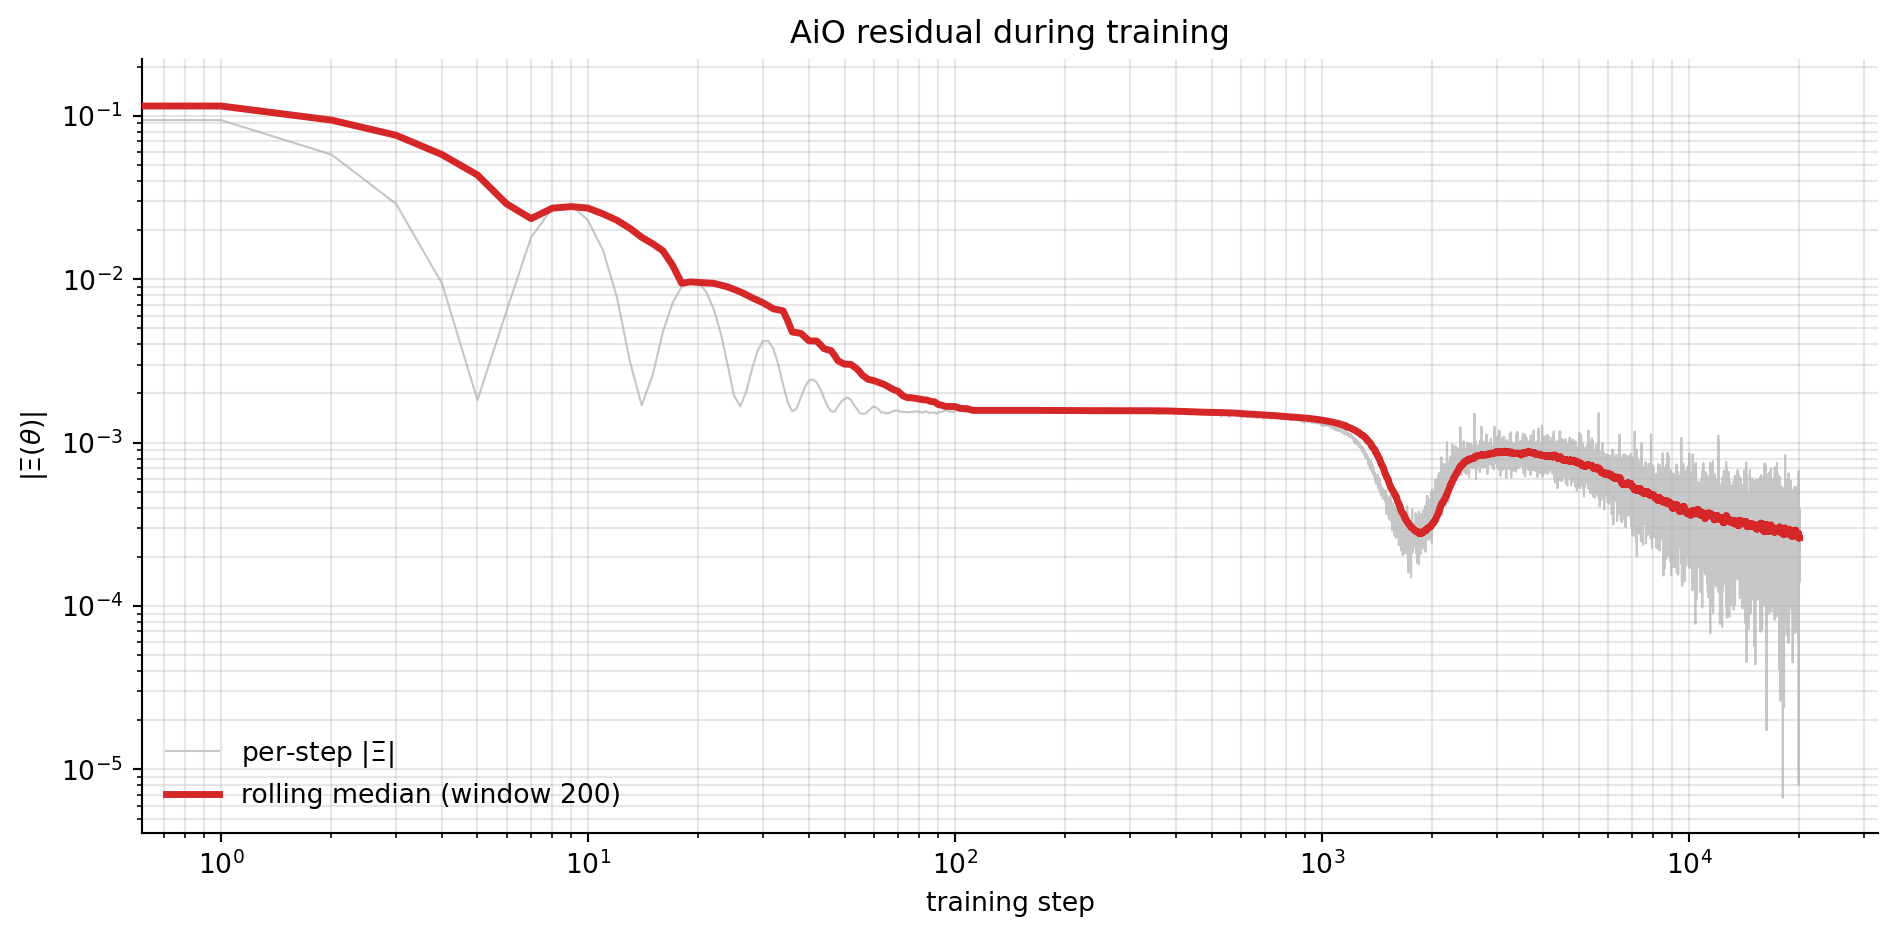

In [11]:
abs_loss = np.abs(losses)
# rolling median to cut through the AiO Monte-Carlo noise and show the trend
win = 200
smooth = np.array(
    [np.median(abs_loss[max(0, i - win) : i + 1]) for i in range(len(abs_loss))]
)

fig, ax = plt.subplots()
ax.plot(abs_loss, lw=0.8, color="0.78", zorder=1, label="per-step $|\\Xi|$")
ax.plot(smooth, lw=2.6, color="C3", zorder=3, label=f"rolling median (window {win})")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_title(
    "AiO residual during training",
)
ax.set_xlabel("training step")
ax.set_ylabel(r"$|\Xi(\theta)|$")
ax.legend(
    loc="lower left",
    frameon=False,
)
ax.grid(alpha=0.3, which="both")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

The loss can be negative on a single draw (the AiO product $R_1^a R_1^b$), so we plot $|\Xi|$.
What matters is the downward trend once training kicks in after burn-in.

# Results and Diagnostics

## Consumption Decision Rule

Sweep one agent's wealth across $[0, w_{\max}]$ at seven income levels, holding everyone else at the
steady state, and read off $c=\zeta\,w$.

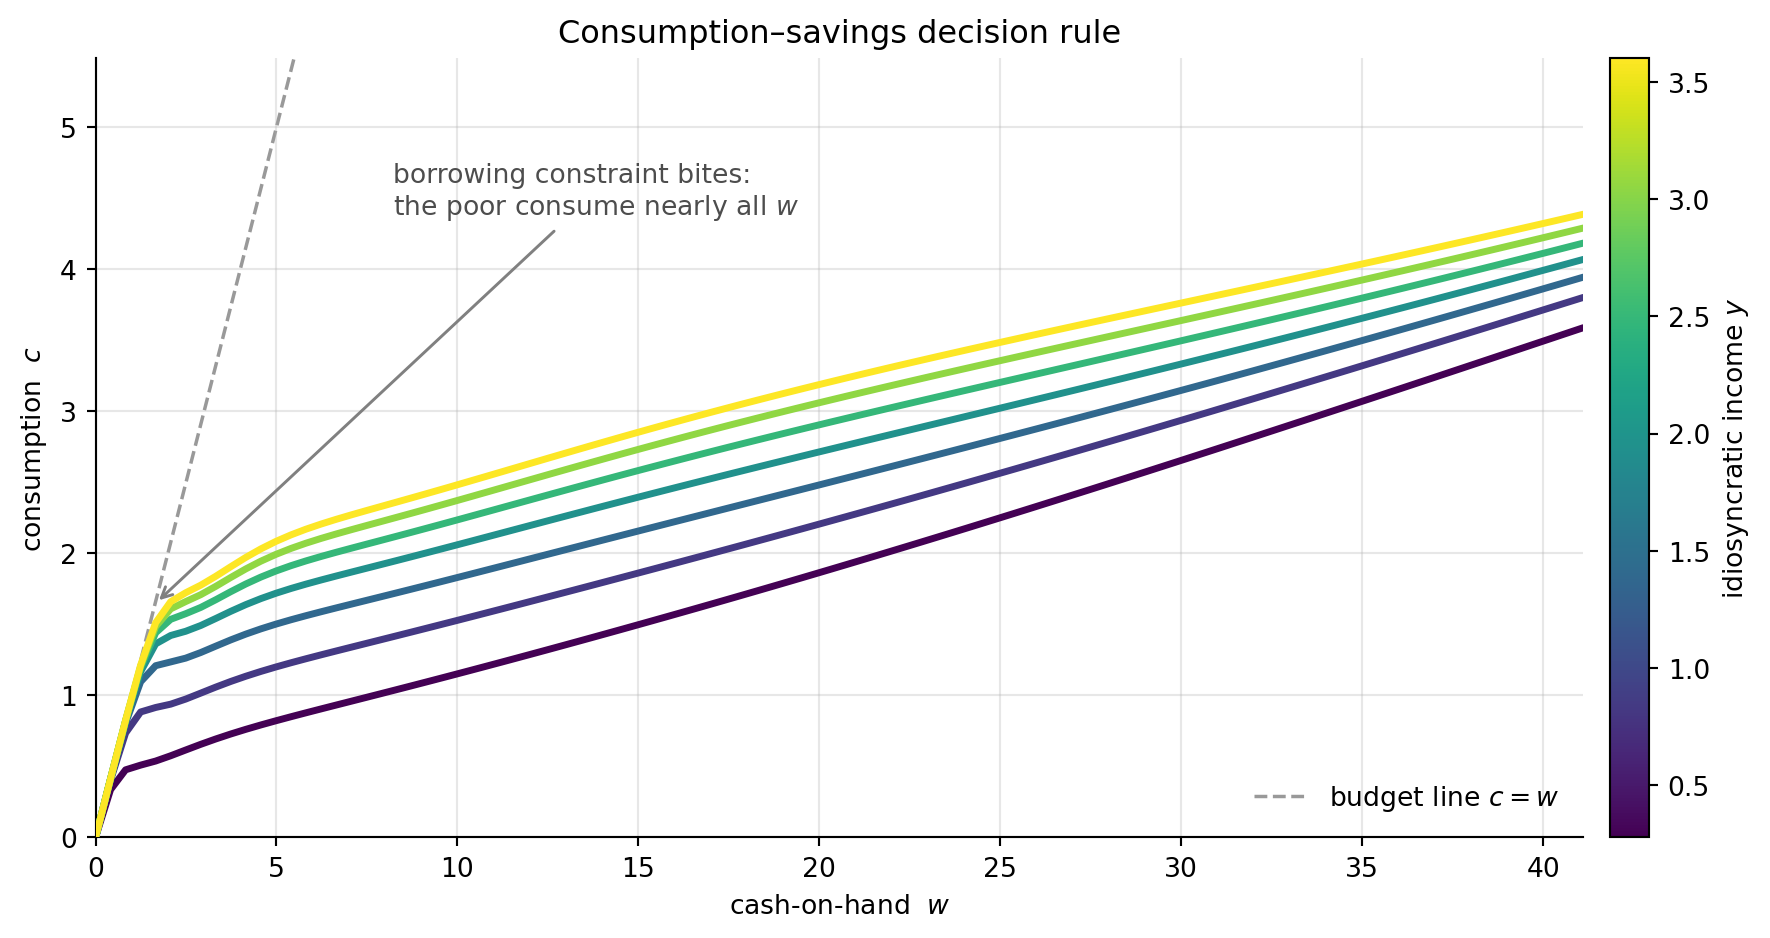

In [12]:
w1 = np.linspace(w_min, w_max, 100).astype(np.float32)
y_values = np.linspace(y_min, y_max, 7).astype(np.float32)
wv, yv, zv = eq_state(100)
wv = wv.at[:, 0].set(jnp.asarray(w1))

# colour each rule by its income level (sequential colormap + colorbar)
norm = Normalize(vmin=y_values.min(), vmax=y_values.max())
cmap = cm.viridis

fig, ax = plt.subplots()
ax.plot(
    w1, w1, ls="--", lw=1.3, color="0.6", zorder=1, label=r"budget line $c=w$"
)  # 45-degree: consuming everything

crules = []
for yi in y_values:
    zeta, _ = policy(model, wv, yv.at[:, 0].set(float(yi)), zv)
    c = np.asarray(zeta)[:, 0] * w1
    crules.append(c)
    ax.plot(w1, c, lw=2.6, color=cmap(norm(yi)), solid_capstyle="round", zorder=3)

# zoom the y-axis to the consumption range so the rules are readable; the 45-line
# (c=w) just exits the top, staying visible near the origin where it matters.
cmax = float(np.max(crules))

# mark the low-wealth region where the constraint bites (policy hugs c=w)
ax.annotate(
    "borrowing constraint bites:\nthe poor consume nearly all $w$",
    xy=(0.04 * w_max, 0.04 * w_max),
    xytext=(0.20 * w_max, 0.80 * cmax * 1.25),
    color="0.30",
    arrowprops=dict(arrowstyle="->", color="0.5", lw=1.1),
)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.015)
cbar.set_label("idiosyncratic income $y$")

ax.set_title(
    "Consumption–savings decision rule",
)
ax.set_xlabel("cash-on-hand  $w$")
ax.set_ylabel("consumption  $c$")
ax.set_xlim(w_min, w_max)
ax.set_ylim(0, cmax * 1.25)
ax.legend(
    loc="lower right",
    frameon=False,
)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

Consumption rises monotonically in wealth and shifts up with income — and bends toward the 45° line
$c=w$ at low wealth, where the borrowing constraint bites.

## Simulation and the Ergodic Distribution

In [13]:
def simulate(model, key, T=1000):
    w, y, z = eq_state(1)

    def step(carry, k):
        w, y, z = carry
        zeta, _ = policy(model, w, y, z)
        a = jnp.minimum((1 - zeta) * w, w_max)
        ey = jr.normal(jr.fold_in(k, 0), (1, N)) * sig_y
        ez = jr.normal(jr.fold_in(k, 1), (1, 1)) * sig_z
        yp, zp = transition(y, z, ey, ez)
        rp, Wp = prices(meanA(a), zp)
        return ((1 + rp) * a + Wp * yp, yp, zp), a[0]

    _, k_array = lax.scan(step, (w, y, z), jr.split(key, T))
    return np.asarray(k_array)  # (T, N) individual capital


k = simulate(model, jr.fold_in(key, 2), 1000)
kmean = k[700:1000].mean(axis=1)
sample = k[700:1000, :5]
print(f"mean capital over last 300 steps = {kmean.mean():.4f}  (K_SS = {K_SS:.4f})")

mean capital over last 300 steps = 5.6924  (K_SS = 5.4468)


---

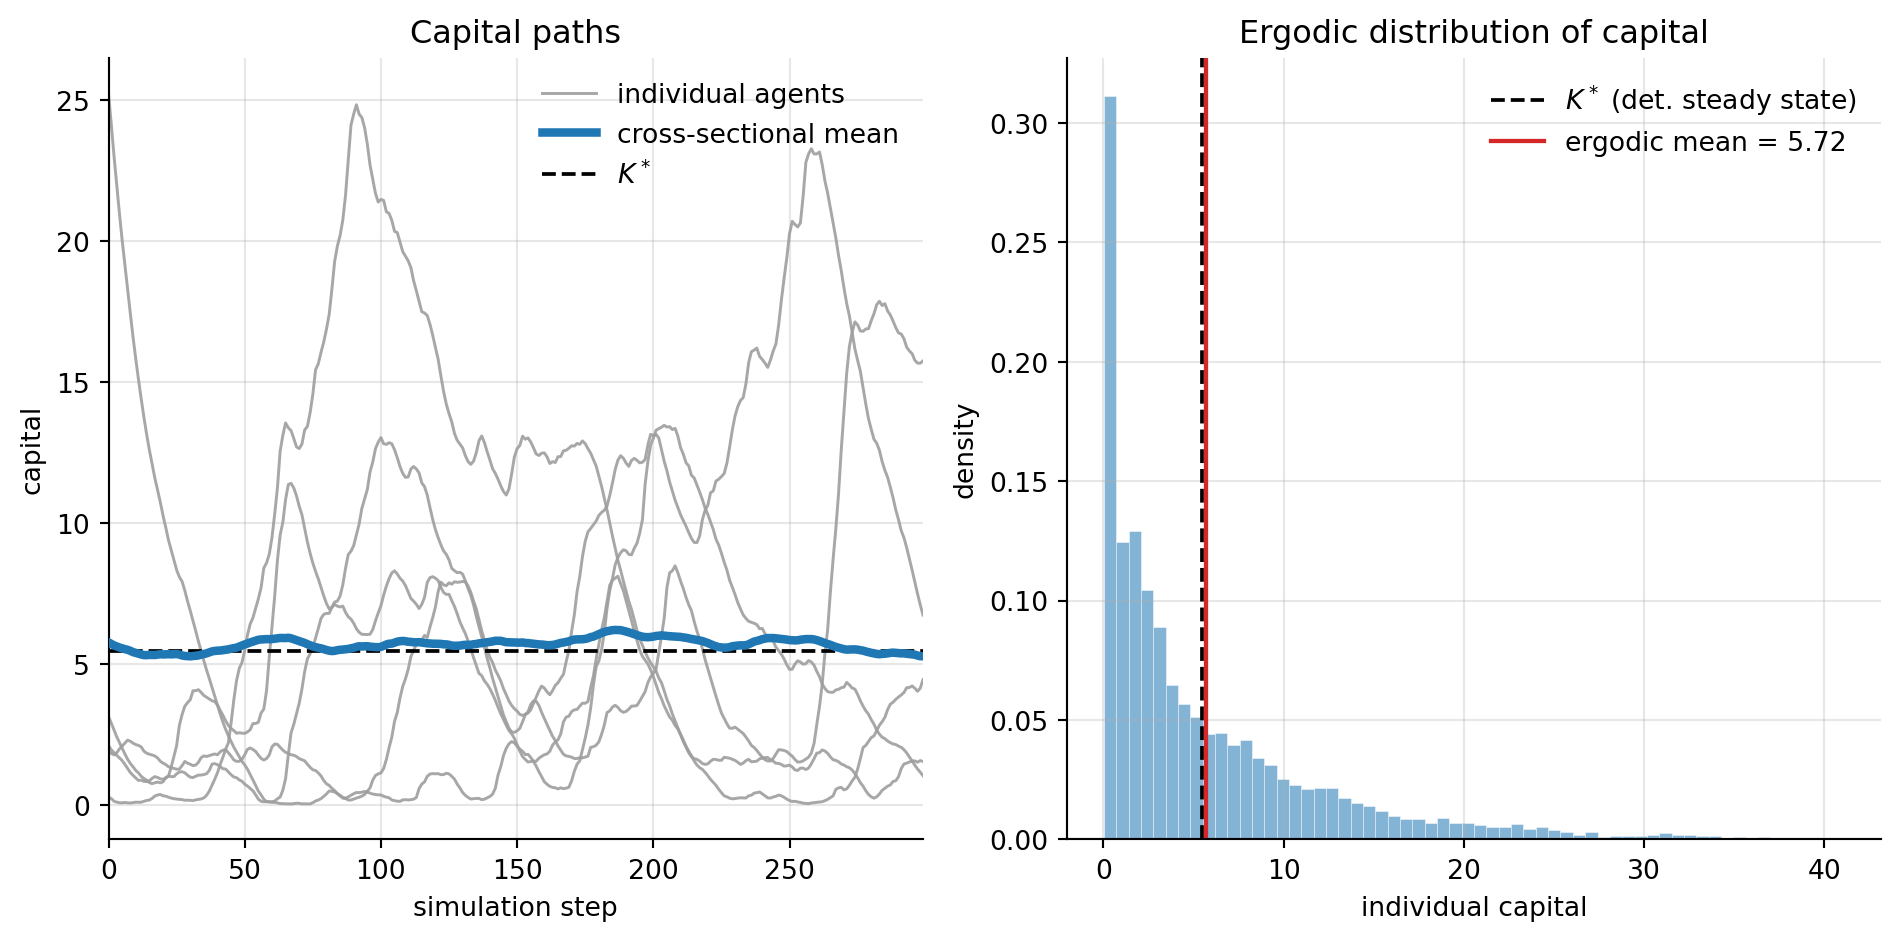

In [14]:
fig, ax = plt.subplots(1, 2)
xa = np.arange(300)

# left: five individual capital paths (muted) + the cross-sectional mean (bold)
for i in range(5):
    ax[0].plot(
        xa,
        sample[:, i],
        lw=1.1,
        color="0.62",
        alpha=0.9,
        label="individual agents" if i == 0 else None,
    )
ax[0].plot(xa, kmean, lw=3.2, color="C0", zorder=4, label="cross-sectional mean")
ax[0].axhline(K_SS, ls="--", lw=1.4, color="k", zorder=3, label="$K^*$")
ax[0].set_title(
    "Capital paths",
)
ax[0].set_xlabel("simulation step")
ax[0].set_ylabel("capital")
ax[0].set_xlim(0, 299)
ax[0].legend(
    loc="upper right",
    frameon=False,
)
ax[0].grid(alpha=0.3)
ax[0].spines[["top", "right"]].set_visible(False)

# right: ergodic (stationary) cross-sectional distribution of capital
flat = k[500:].ravel()
ax[1].hist(
    flat, bins=60, density=True, color="C0", alpha=0.55, edgecolor="white", lw=0.3
)
ax[1].axvline(K_SS, ls="--", lw=1.4, color="k", label="$K^*$ (det. steady state)")
ax[1].axvline(
    flat.mean(), ls="-", lw=1.6, color="C3", label=f"ergodic mean = {flat.mean():.2f}"
)
ax[1].set_title(
    "Ergodic distribution of capital",
)
ax[1].set_xlabel("individual capital")
ax[1].set_ylabel("density")
ax[1].legend(
    loc="upper right",
    frameon=False,
)
ax[1].grid(alpha=0.3)
ax[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

The cross-sectional **mean** sits a little **above** $K^*$, and *individual* capital has a
non-degenerate, right-skewed **ergodic distribution** — exactly the object classical KS summarizes by a
single number.




## Why mean capital $>K^*$ — and why that is two things at once
- **Economics (real).** $K^*$ is the *deterministic* steady state ($1+r=1/\beta$, no risk). With
  uninsurable income risk and a borrowing constraint, agents save extra for self-insurance —
  **precautionary saving** — so the ergodic capital stock *should* exceed $K^*$. This is the signature
  Aiyagari/Krusell-Smith result.
- **Numerics (caveat).** Part of the gap is accuracy: at ~1% Euler errors, **aggregates are a
  *sensitive* function of the policy** — small per-period errors accumulate over the stationary
  distribution into a bias in $K$. Tellingly, the ergodic mean is itself sensitive to network size,
  batch, and seed — across our runs it has ranged from roughly $5.5$ to $6.0$.

**Takeaway:** *accurate decision rules $\neq$ accurate aggregates.* A policy that looks great on the
decision-rule plot can still misprice the capital stock — which is exactly why we never trust the eye
and instead report the **Euler-error** check next.

## Inequality in the Stationary Distribution

The full cross-section the network carries is not a curiosity — it *is* the wealth distribution. Read
standard inequality statistics straight off the ergodic panel.

Gini = 0.573   top-10% share = 37.4%   top-1% share = 6.0%   near-constraint = 14.2%


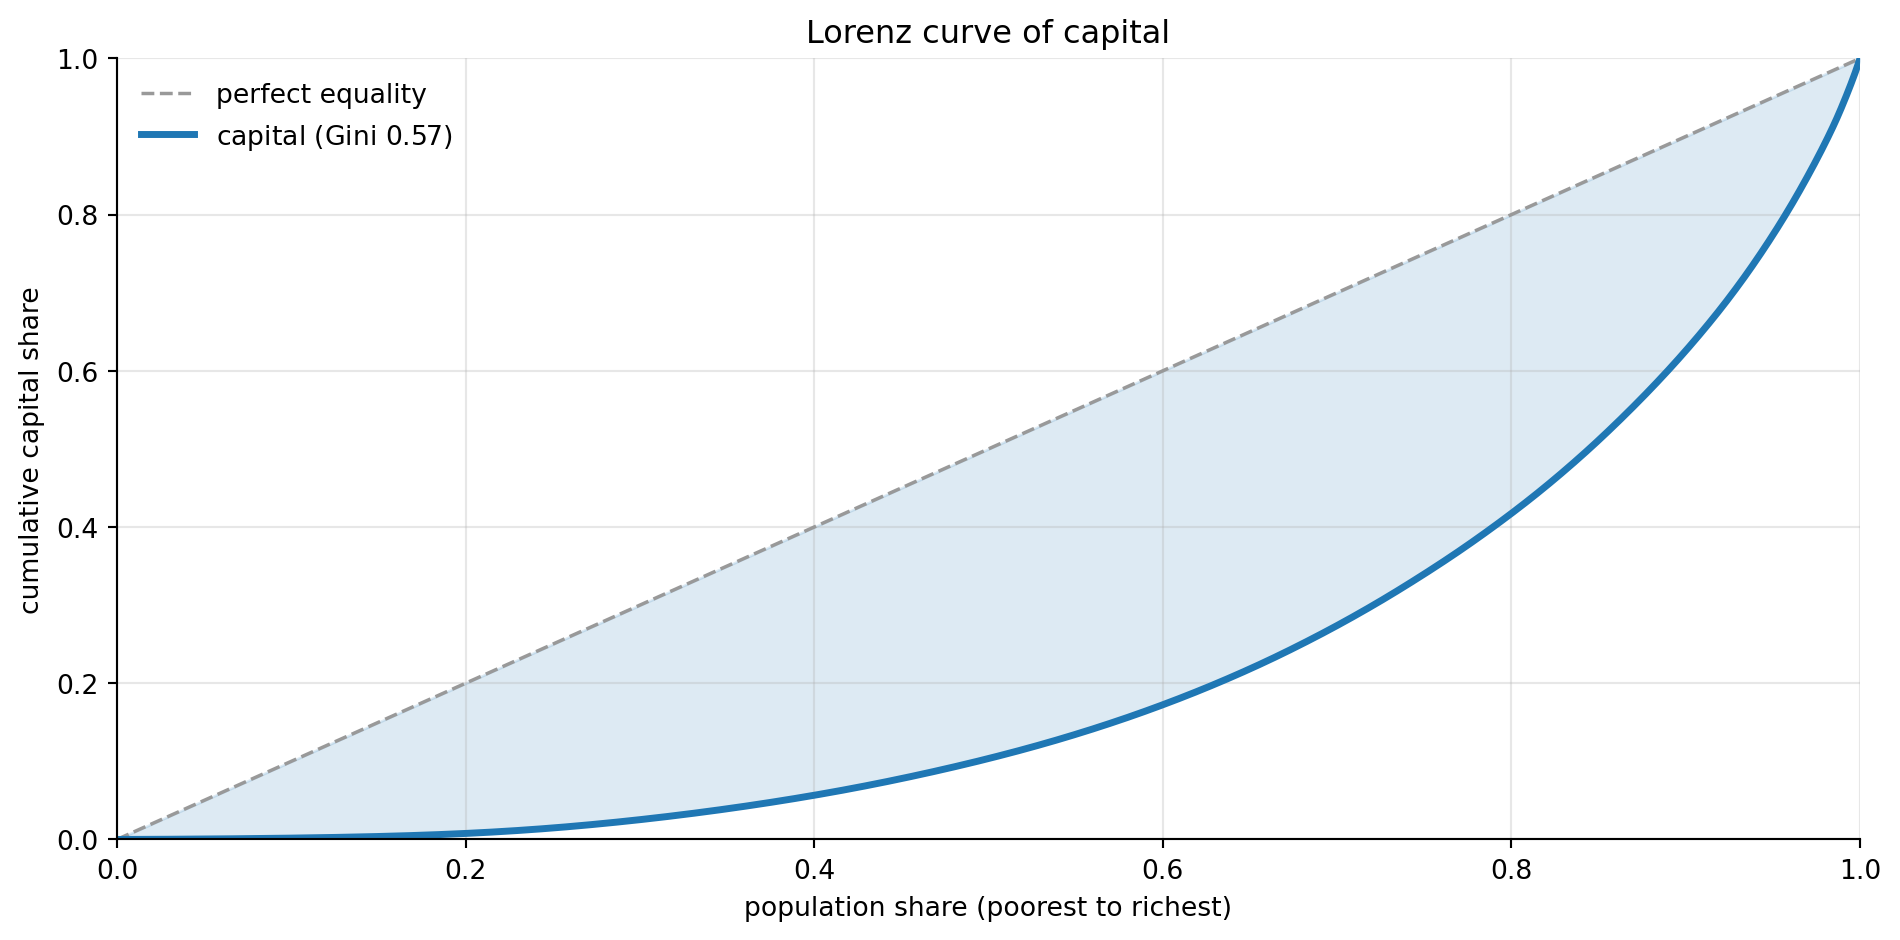

In [15]:
cap = np.sort(flat)  # individual capital over the ergodic panel (>= 0)
ncap = cap.size
gini = (2 * np.sum(np.arange(1, ncap + 1) * cap) - (ncap + 1) * cap.sum()) / (
    ncap * cap.sum()
)
top10 = cap[int(0.9 * ncap) :].sum() / cap.sum()
top1 = cap[int(0.99 * ncap) :].sum() / cap.sum()
near_constraint = float(np.mean(flat < 0.05 * flat.mean()))
print(
    f"Gini = {gini:.3f}   top-10% share = {top10:.1%}   "
    f"top-1% share = {top1:.1%}   near-constraint = {near_constraint:.1%}"
)

lorenz = np.concatenate([[0.0], np.cumsum(cap) / cap.sum()])
popshare = np.linspace(0, 1, ncap + 1)
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], ls="--", lw=1.3, color="0.6", label="perfect equality")
ax.plot(popshare, lorenz, lw=2.6, color="C0", label=f"capital (Gini ${gini:.2f}$)")
ax.fill_between(popshare, lorenz, popshare, color="C0", alpha=0.15)
ax.set_title("Lorenz curve of capital")
ax.set_xlabel("population share (poorest to richest)")
ax.set_ylabel("cumulative capital share")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left", frameon=False)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Aggregate Dynamics: Prices Move with the Shock

Because the gross return is $1+r_t = 1-\delta+\alpha z_t K_t^{\alpha-1}$, the **aggregate shock $z$ makes
factor prices fluctuate** — the feature Aiyagari shuts off and KS turns on.

In [16]:
def simulate_prices(model, key, T=600):
    w, y, z = eq_state(1)

    def step(carry, kk):
        w, y, z = carry
        zeta, _ = policy(model, w, y, z)
        a = jnp.minimum((1 - zeta) * w, w_max)
        ey = jr.normal(jr.fold_in(kk, 0), (1, N)) * sig_y
        ez = jr.normal(jr.fold_in(kk, 1), (1, 1)) * sig_z
        yp, zp = transition(y, z, ey, ez)
        r, W = prices(meanA(a), zp)
        return ((1 + r) * a + W * yp, yp, zp), (zp[0, 0], r[0, 0], W[0, 0])

    _, (zs, rs, Ws) = lax.scan(step, (w, y, z), jr.split(key, T))
    return (
        np.asarray(zs[100:]),
        np.asarray(rs[100:]),
        np.asarray(Ws[100:]),
    )  # drop burn-in


zs, rs, Ws = simulate_prices(model, jr.fold_in(key, 3))

---

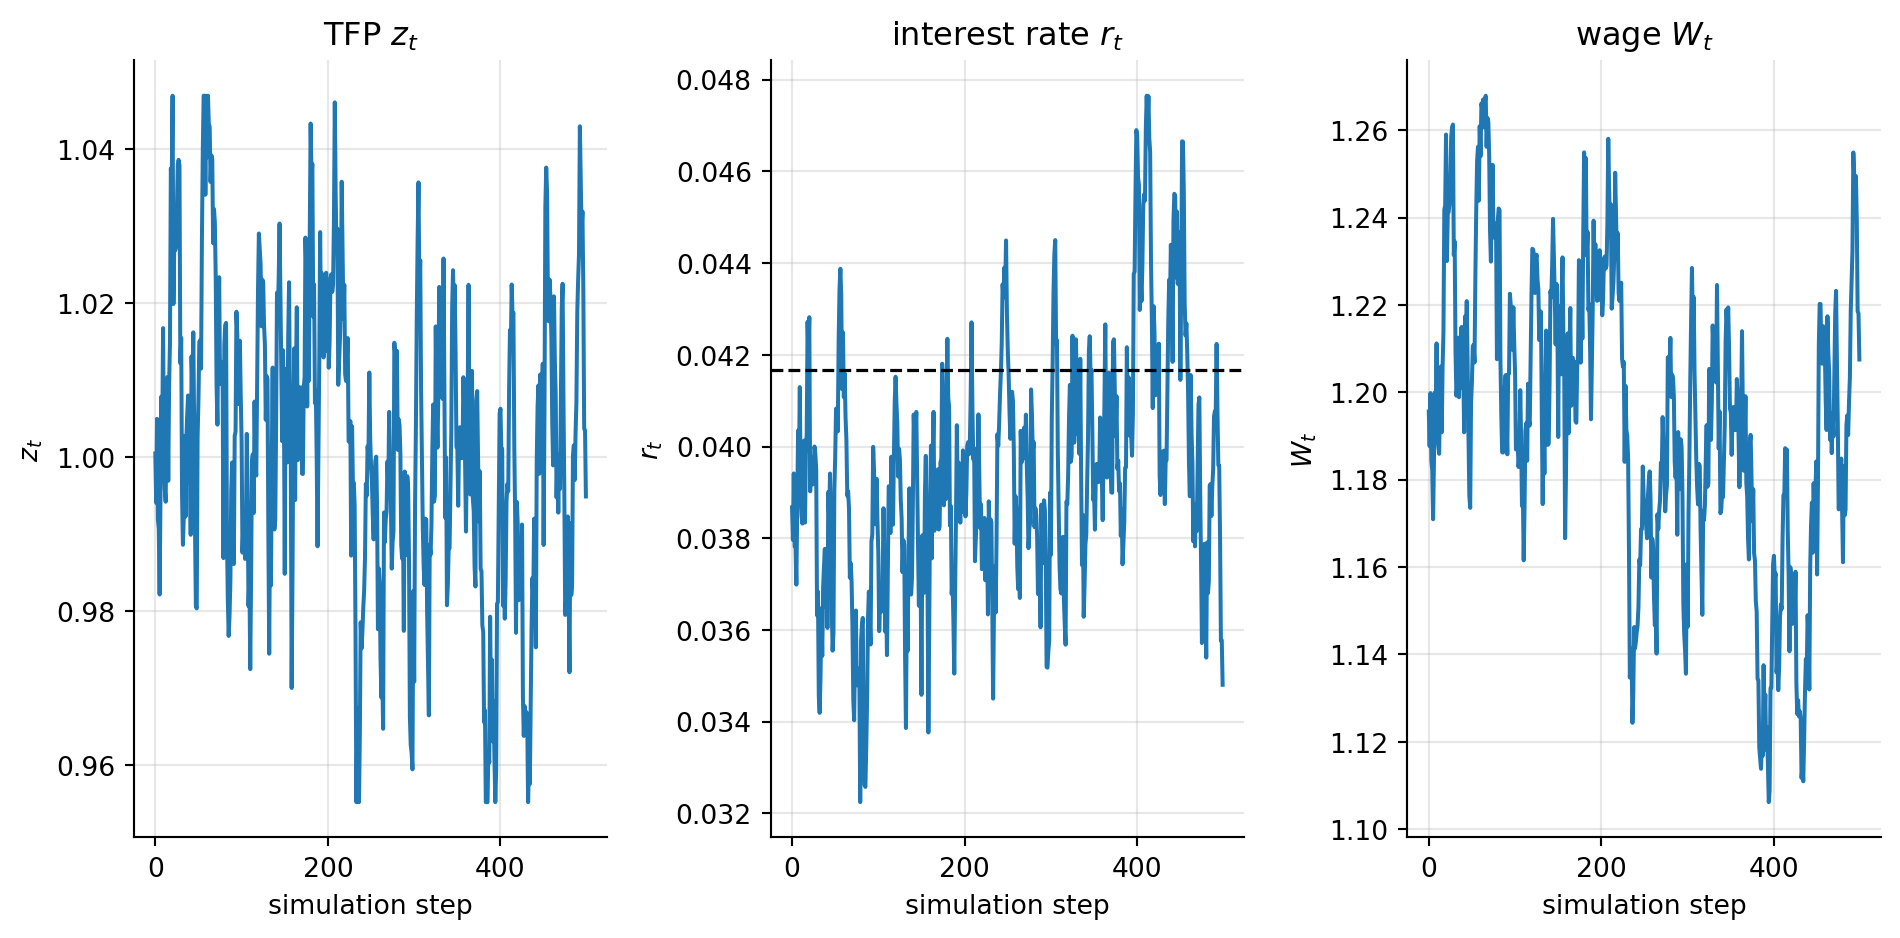

In [17]:
t_ax = np.arange(zs.size)
fig, ax = plt.subplots(1, 3)
for a_, s, ttl, yl in zip(
    ax,
    [zs, rs, Ws],
    ["TFP $z_t$", "interest rate $r_t$", "wage $W_t$"],
    ["$z_t$", "$r_t$", "$W_t$"],
):
    a_.plot(t_ax, s, lw=1.5, color="C0")
    a_.set_title(ttl)
    a_.set_xlabel("simulation step")
    a_.set_ylabel(yl)
    a_.grid(alpha=0.3)
    a_.spines[["top", "right"]].set_visible(False)
ax[1].axhline(1 / beta - 1, ls="--", lw=1.2, color="k")  # deterministic r*
fig.tight_layout()
plt.show()

Prices wander in a narrow band — $\sigma_z$ is small in this calibration — but the point stands: returns
are an equilibrium outcome of the whole distribution, recomputed every period.

## Impulse Response to a TFP Shock

Hit the economy with a one-time aggregate-TFP innovation, hold idiosyncratic shocks at zero, and trace
the response *relative to* an unshocked baseline (so any drift from an imperfect policy cancels).

In [18]:
def agg_path(model, ez0, T=40):
    w, y, z = eq_state(1)
    Ks, rs_, zs_ = [], [], []
    for t in range(T):
        zeta, _ = policy(model, w, y, z)
        a = jnp.minimum((1 - zeta) * w, w_max)
        ez = jnp.array([[ez0 if t == 0 else 0.0]])
        yp, zp = transition(y, z, jnp.zeros((1, N)), ez)
        r, W = prices(meanA(a), zp)
        Ks.append(float(meanA(a)[0, 0]))
        rs_.append(float(r[0, 0]))
        zs_.append(float(zp[0, 0]))
        w, y, z = (1 + r) * a + W * yp, yp, zp
    return np.array(Ks), np.array(rs_), np.array(zs_)


sig_e_z = sig_z / np.sqrt(1 - rho_z**2)  # ergodic std of log z
K0, r0, z0 = agg_path(model, 0.0)  # baseline (no shock)
K1, r1, z1 = agg_path(model, sig_e_z)  # +1 ergodic-std TFP shock

---

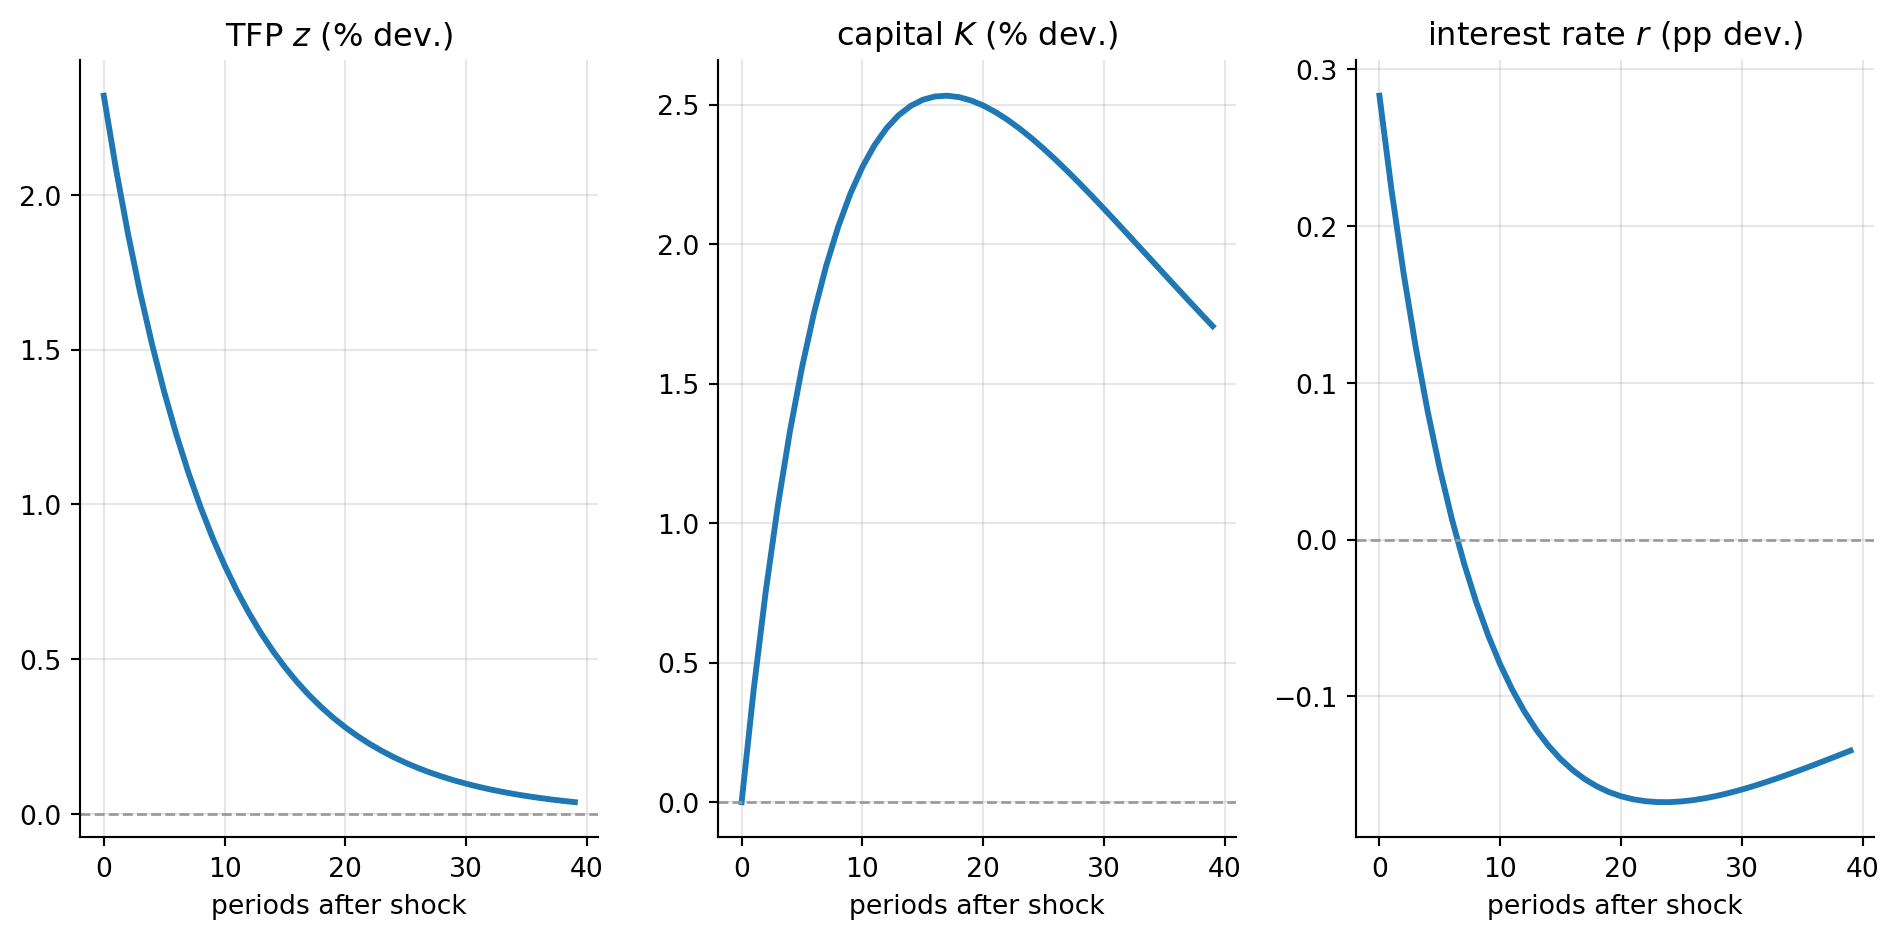

In [19]:
hh = np.arange(K0.size)
fig, ax = plt.subplots(1, 3)
ax[0].plot(hh, 100 * (z1 - z0), lw=2.2, color="C0")
ax[0].set_title("TFP $z$ (% dev.)")
ax[1].plot(hh, 100 * (K1 - K0) / K0, lw=2.2, color="C0")
ax[1].set_title("capital $K$ (% dev.)")
ax[2].plot(hh, 100 * (r1 - r0), lw=2.2, color="C0")
ax[2].set_title("interest rate $r$ (pp dev.)")
for a_ in ax:
    a_.axhline(0, ls="--", lw=1, color="0.6")
    a_.set_xlabel("periods after shock")
    a_.grid(alpha=0.3)
    a_.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

A positive TFP shock lifts the return on impact; **capital then builds up and slowly mean-reverts** as
$z$ decays at rate $\rho_z$ — a textbook aggregate transition, produced by the *same* neural policy with
no extra solving.

## Accuracy: DenHaan-Style Euler Errors

The training loss is a *noisy* AiO estimate. The honest accuracy check evaluates the **unit-free Euler
residual** $1 - \beta\,\mathbb E[(1+r')u'(c')]/u'(c)$ with *many* inner shocks, on states the economy
actually visits, and reports $\log_{10}|\text{residual}|$.

In [20]:
def euler_errors(model, key, T=1500, burn=500, M=100):
    w, y, z = eq_state(1)
    ws = []
    k = key
    for t in range(T):  # collect an ergodic path
        k, kk = jr.split(k)
        zeta, _ = policy(model, w, y, z)
        a = jnp.minimum((1 - zeta) * w, w_max)
        yp, zp = transition(
            y,
            z,
            jr.normal(jr.fold_in(kk, 0), (1, N)) * sig_y,
            jr.normal(jr.fold_in(kk, 1), (1, 1)) * sig_z,
        )
        rp, Wp = prices(meanA(a), zp)
        w, y, z = (1 + rp) * a + Wp * yp, yp, zp
        if t >= burn:
            ws.append((w, y, z))
    W_, Y_, Z_ = (jnp.concatenate([s[i] for s in ws], 0) for i in range(3))

    zeta, h = policy(model, W_, Y_, Z_)
    a = jnp.minimum((1 - zeta) * W_, w_max)
    mu_c = u_prime(zeta * W_)

    def draw(kk):  # one inner Monte-Carlo draw
        rp, cp = euler_next(
            model,
            a,
            Y_,
            Z_,
            jr.normal(jr.fold_in(kk, 0), W_.shape) * sig_y,
            jr.normal(jr.fold_in(kk, 1), (W_.shape[0], 1)) * sig_z,
        )
        return (1 + rp) * u_prime(cp)

    Eterm = jnp.mean(jax.vmap(draw)(jr.split(jr.fold_in(key, 7), M)), axis=0)
    resid = 1 - beta * Eterm / mu_c
    return np.asarray(jnp.log10(jnp.abs(resid) + 1e-12)), np.asarray(h > 0.999)


log_err, _ = euler_errors(model, jr.fold_in(key, 5))
print(
    f"log10 Euler error:  mean={log_err.mean():.2f}   median={np.median(log_err):.2f}   "
    f"max={log_err.max():.2f}"
)

log10 Euler error:  mean=-2.11   median=-2.01   max=-0.82


---

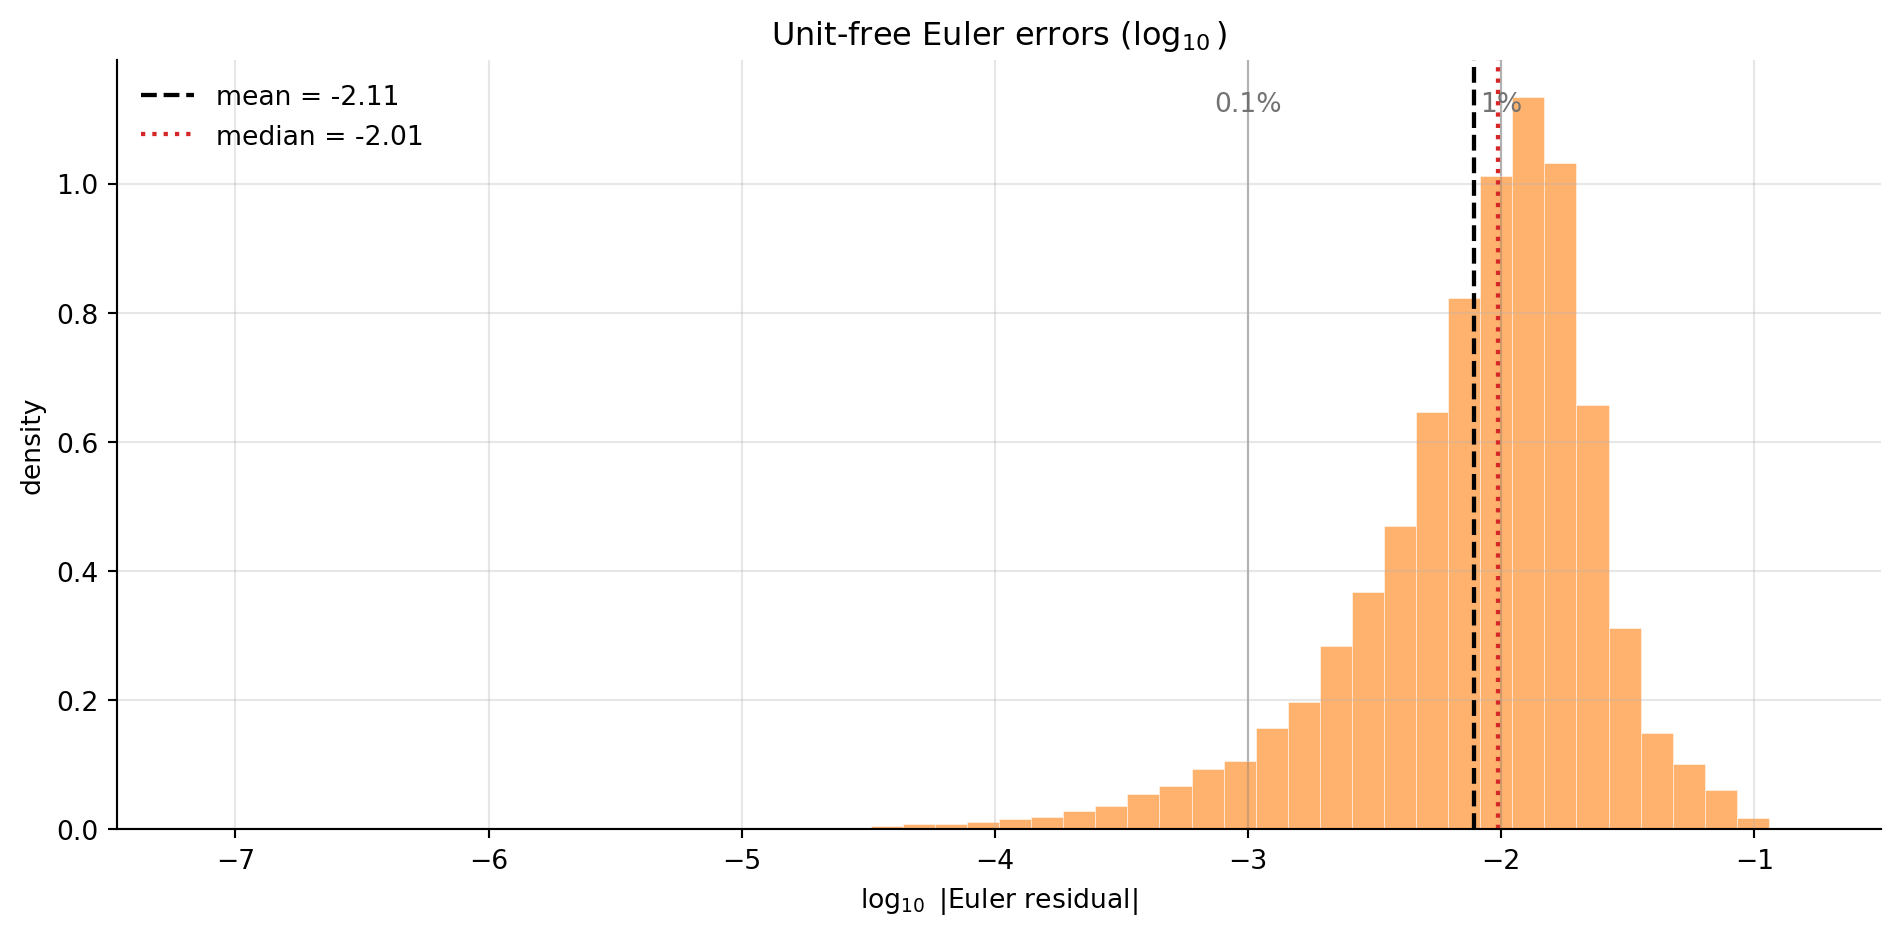

In [21]:
le = log_err.ravel()
fig, ax = plt.subplots()
ax.hist(le, bins=50, density=True, color="C1", alpha=0.6, edgecolor="white", lw=0.3)
ax.axvline(le.mean(), ls="--", lw=1.6, color="k", label=f"mean = {le.mean():.2f}")
ax.axvline(
    np.median(le), ls=":", lw=1.6, color="C3", label=f"median = {np.median(le):.2f}"
)
# reference guides: 1% and 0.1% Euler errors
for lvl, txt in [(-2, "1%"), (-3, "0.1%")]:
    ax.axvline(lvl, ls="-", lw=0.8, color="0.7", zorder=0)
    ax.text(
        lvl,
        ax.get_ylim()[1] * 0.96,
        txt,
        ha="center",
        va="top",
        color="0.45",
    )
ax.set_title(
    r"Unit-free Euler errors ($\log_{10}$)",
)
ax.set_xlabel(r"$\log_{10}$ |Euler residual|")
ax.set_ylabel("density")
ax.legend(
    loc="upper left",
    frameon=False,
)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

A mean around $-2$ means a typical Euler error of $\sim 1\%$ — good enough to read the economics off the
solution. The next slide explains the two honest levers that push it lower.

## Pushing the Residual Lower

First, read the right number. The **training loss is noisy**: the AiO term $R_1^a R_1^b$ is an
*unbiased but high-variance* estimate, so $|\Xi|$ flattens at a Monte-Carlo **noise floor** and even goes
negative. The honest accuracy metric is the **Euler-error histogram** above.

Two levers move it — both with a clean economic / statistical reading, no black-box tricks:

::::{.columns}
:::{.column width="50%"}
**1. A richer approximating family**

- Wider / deeper network = more flexible $\varphi(\cdot;\theta)$ (universal approximation).
- Here: **3 hidden layers of 64** (vs the original $16\times2$).
- Lowers *approximation* error — the policy it *can* represent.
:::
:::{.column width="50%"}
**2. More Monte-Carlo samples**

- Larger **`BATCH`** = more parallel economies per step.
- Gradient-noise shrinks like $1/\sqrt{B}$, so SGD settles lower.
- Here: **`BATCH=512`**. Lowers *sampling* error — and it is exactly *what saturates more CPU/GPU cores*.
:::
::::

## Does Approximate Aggregation Hold?

Classical KS *assumes* a single moment $K$ (plus $z$) forecasts next-period $K'$ well. Our network never
assumed this — it used the whole distribution. So we can **test** it: fit the KS forecasting rule
$\log K' = a_0 + a_1 \log K + a_2 \log z$ to the simulated path and measure its **Den Haan error**.

In [22]:
def simulate_klom(model, key, T=2500):
    w, y, z = eq_state(1)

    def step(carry, kk):
        w, y, z = carry
        zeta, _ = policy(model, w, y, z)
        a = jnp.minimum((1 - zeta) * w, w_max)
        ey = jr.normal(jr.fold_in(kk, 0), (1, N)) * sig_y
        ez = jr.normal(jr.fold_in(kk, 1), (1, 1)) * sig_z
        yp, zp = transition(y, z, ey, ez)
        r, W = prices(meanA(a), zp)
        return ((1 + r) * a + W * yp, yp, zp), (meanA(a)[0, 0], z[0, 0])

    _, (S, zt) = lax.scan(step, (w, y, z), jr.split(key, T))
    return np.asarray(S), np.asarray(zt)


S, zt = simulate_klom(model, jr.fold_in(key, 4))
burn0 = 500
lKp = np.log(S[burn0:])  # log K_{t+1} (= log mean-savings)
lK = np.log(S[burn0 - 1 : -1])  # log K_t
lz = np.log(zt[burn0:])  # log z_t
X = np.column_stack([np.ones_like(lK), lK, lz])
coef, *_ = np.linalg.lstsq(X, lKp, rcond=None)
R2 = 1 - np.sum((lKp - X @ coef) ** 2) / np.sum((lKp - lKp.mean()) ** 2)

# Den Haan error: iterate the fitted rule on its OWN forecast, compare to the path
Khat = np.empty_like(lKp)
Khat[0] = lK[0]
for t in range(1, Khat.size):
    Khat[t] = coef[0] + coef[1] * Khat[t - 1] + coef[2] * lz[t]
dh = 100 * np.abs(Khat - lKp)
print(
    f"forecasting-rule R^2 = {R2:.5f}    "
    f"Den Haan error: mean = {dh.mean():.3f}%   max = {dh.max():.3f}%"
)

forecasting-rule R^2 = 0.99851    Den Haan error: mean = 2.050%   max = 6.616%


---

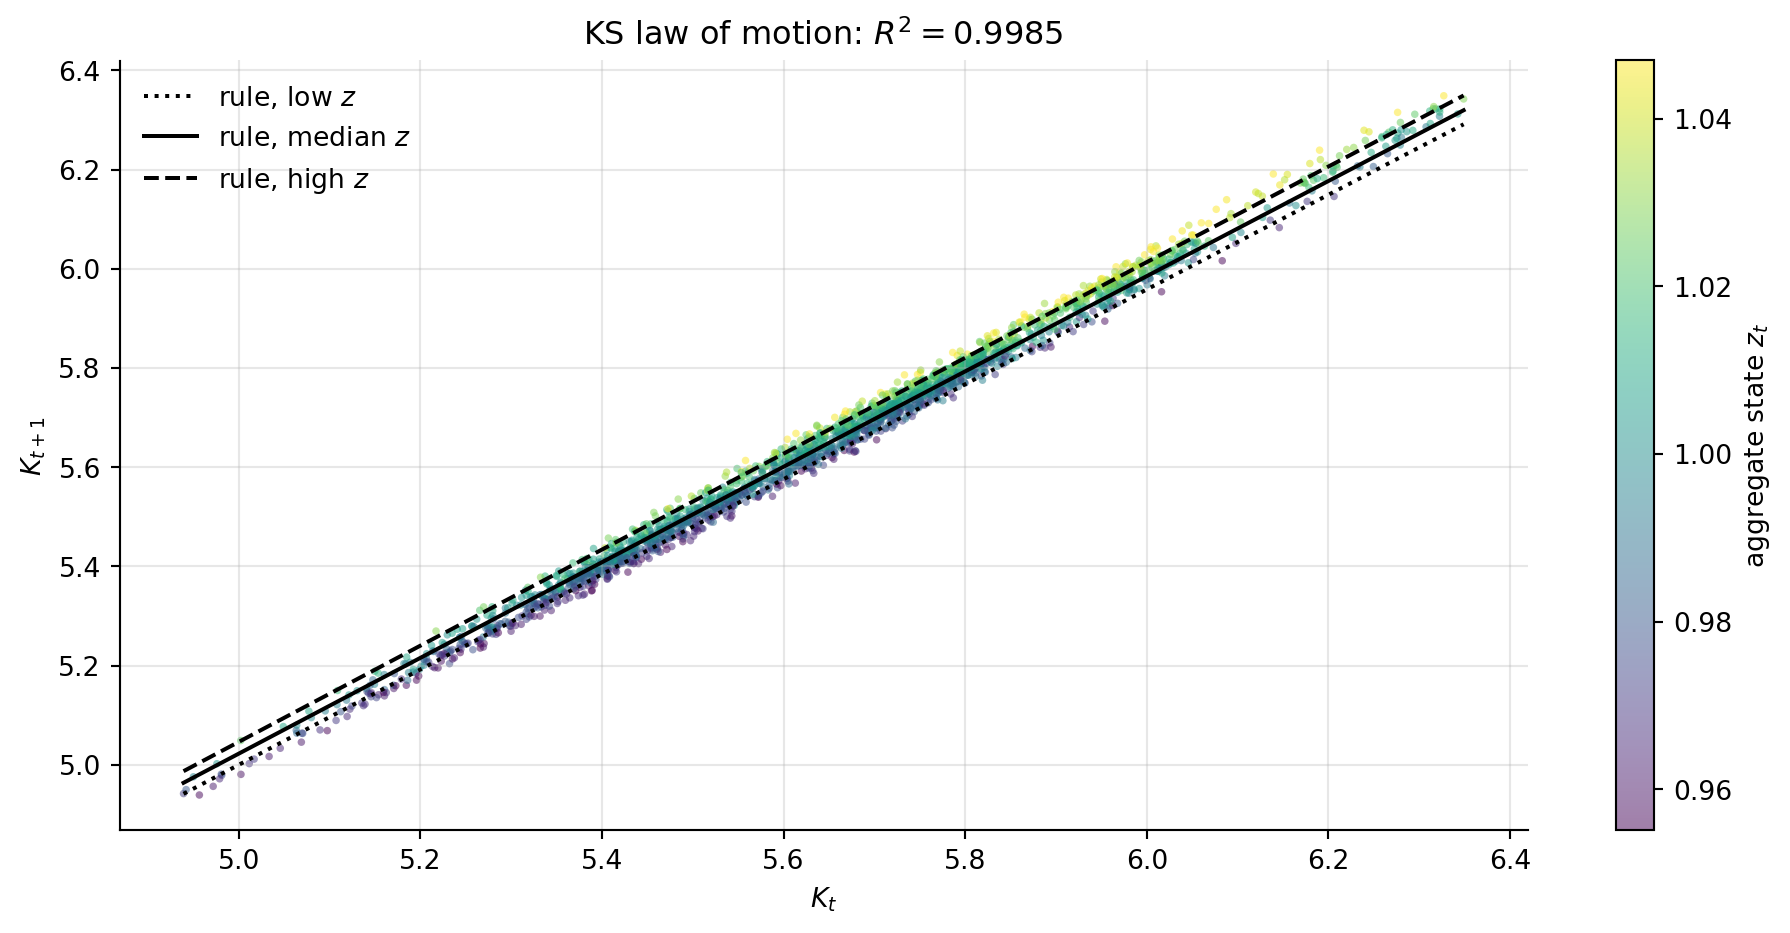

In [23]:
# Law of motion in (K_t, K_{t+1}) space: the cloud is coloured by the aggregate
# state z_t, and the fitted rule is drawn at low / median / high z. This shows
# BOTH regressors — capital persistence (slope in K) and the z-shift.
K_t, K_t1 = np.exp(lK), np.exp(lKp)
zc = zt[burn0:]  # aggregate state z_t (colour)
kg = np.linspace(lK.min(), lK.max(), 50)
fig, ax = plt.subplots()
sc = ax.scatter(K_t, K_t1, c=zc, s=8, alpha=0.5, cmap="viridis", edgecolor="none")
for q, ls, lab in zip(
    np.percentile(lz, [10, 50, 90]), [":", "-", "--"], ["low $z$", "median $z$", "high $z$"]
):
    ax.plot(np.exp(kg), np.exp(coef[0] + coef[1] * kg + coef[2] * q),
            color="k", lw=1.5, ls=ls, label=f"rule, {lab}")
fig.colorbar(sc).set_label("aggregate state $z_t$")
ax.set_title(f"KS law of motion: $R^2 = {R2:.4f}$")
ax.set_xlabel("$K_t$")
ax.set_ylabel("$K_{t+1}$")
ax.legend(loc="upper left", frameon=False)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

The fit is striking — $R^2 \approx 0.998$, so the two moments $K$ and $z$ already explain almost all of
next period's $K'$: **approximate aggregation roughly holds**, just as KS conjectured. 


# Regularization

## Why Regularize a Neural Network Solution?

The network has many more parameters than the economics pins down. Two failure modes:

- **Overfitting the sample path.** We train on *simulated* states; the network can fit the noise of the
  particular draws rather than the underlying policy.
- **Rough, wiggly policies.** An unconstrained MLP can interpolate with high-curvature wiggles between
  visited states — bad for accuracy *off* the simulated path and for stable simulation.

**L2 weight regularization** adds $\lambda\sum_\ell \lVert W_\ell\rVert_2^2$ to the loss. It shrinks
weights toward zero, which:

- damps high-frequency wiggles (smoother decision rules);
- improves generalization to states slightly off the ergodic path;
- stabilizes the joint *simulate-and-train* loop, where policy and distribution co-evolve.

## L2 in the Loss

We already added it — one line, applied to the **weight matrices only** (not biases):

In [24]:
print("L2 penalty term at the trained model:", float(l2_penalty(model)))
print("final data residual (loss - penalty) :", float(losses[-1] - l2_penalty(model)))

L2 penalty term at the trained model: 7.40026954515801e-05
final data residual (loss - penalty) : 0.00018446848179219855


::: {.callout-tip}
### Tuning $\lambda$
- $\lambda$ too small $\Rightarrow$ no effect; too large $\Rightarrow$ the penalty dominates and the
  network underfits the Euler equation.
- Here $\lambda = 10^{-7}$ looks tiny, but with the wider $64{\times}3$ network it still shrinks the
  weights enough to keep the policy smooth — the penalty ends up a modest share of the loss, not a
  dominant one. Treat $\lambda$ as a hyperparameter — sweep it and watch the Euler-error histogram.
- Equivalent alternatives in `optax`: `optax.add_decayed_weights`, or `optax.adamw` (decoupled weight
  decay). Adding the penalty to the loss, as here, is the most transparent.
:::

# Wrap-Up

## What We Built

- A **50-agent Krusell-Smith** model **with aggregate shocks**, solved **globally** by one neural
  network — the concrete payoff of the previous deck's machinery.
- Same toolkit (FB + AiO + Adam + autodiff), just a **richer state and two shock sources**.
- **No approximate aggregation**: the full cross-section is the network's input, handled by `vmap`.
- Trains in **about fifteen minutes on CPU** (much faster on GPU) thanks to an end-to-end `lax.scan` online training loop.

## Threads to Pull

- **Scale agents** with permutation-invariant architectures [@kahou_fernandez_villaverde_perla_sood_2024_symmetry; @han_yang_e_2025_deepham].
- **Let $L$ float** (drop the mean-1 normalization) for genuine aggregate labor dynamics.
- **Sharper accuracy**: learning-rate schedule, wider/deeper network, more steps; track the Euler-error histogram.
- **Compare** head-to-head with classical KS forecasting-rule accuracy (DenHaan errors) on the same calibration.

# References